In [1]:
# This cell is removed with the tag: "remove-input"
# As such, it will not be shown in documentation

import warnings
warnings.filterwarnings('ignore')


(Tutorial_Get_distances)=
# Get distances

*Getting the distance between specific elements of a molecular system or two different molecular systems.*

The function {func}`molsysmt.structure.get_distances` calculates Euclidean distances between atoms, residue groups, geometric centers, or whole systems across structures and simulation frames.

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

Follow this link for a detailed description of the input arguments, raised errors, and returned objects of this function: {func}`molsysmt.structure.get_distances`.
:::


## Basic usage

Let's show the main modes of distance calculations on a pentalanine trajectory:


In [2]:
import molsysmt as msm
import numpy as np
import matplotlib.pyplot as plt


In [3]:
molsys = msm.convert(msm.systems['pentalanine']['traj_pentalanine.h5'], to_form='molsysmt.MolSys')


:::{note} Demo Systems Catalog
:class: dropdown

This tutorial uses demonstration datasets provided by MolSysMT. To explore the full catalog of bundled systems, forms, and file paths, visit the {ref}`Demo Systems <user-foundations-entrance-demo-systems>` guide.
:::


### Distance between specific atoms across trajectory

We calculate the distance between atom `0` and atom `10` along all 5000 simulation frames and plot its time series:


In [4]:
distances = msm.structure.get_distances(molsys, selection=0, selection_2=10)
time = msm.get(molsys, element='system', time=True)
time_ns = msm.pyunitwizard.convert(time, to_unit='ns')


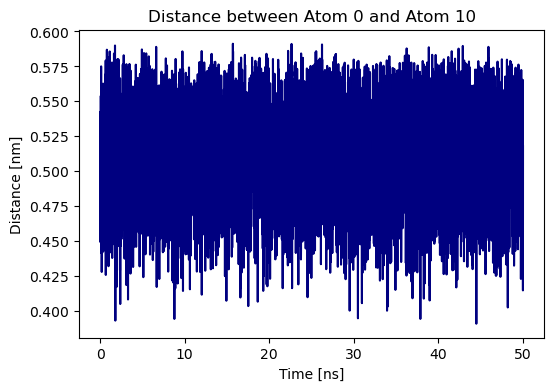

In [5]:
plt.figure(figsize=(6, 4))
plt.plot(time_ns, distances[:, 0, 0], color='navy')
plt.xlabel('Time [ns]')
plt.ylabel('Distance [nm]')
plt.title('Distance between Atom 0 and Atom 10')
plt.show()


### Distance between geometric centers of residue groups

Setting `center_of_atoms=True` and `center_of_atoms_2=True` calculates the end-to-end distance between terminal residue centers:


In [6]:
terminal_dist = msm.structure.get_distances(molsys, selection='group_index==0', selection_2='group_index==4', center_of_atoms=True, center_of_atoms_2=True)


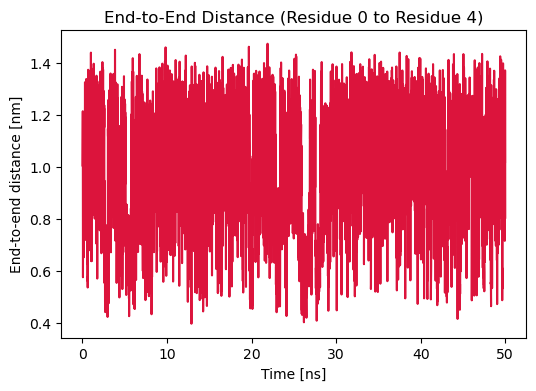

In [7]:
plt.figure(figsize=(6, 4))
plt.plot(time_ns, terminal_dist[:, 0, 0], color='crimson')
plt.xlabel('Time [ns]')
plt.ylabel('End-to-end distance [nm]')
plt.title('End-to-End Distance (Residue 0 to Residue 4)')
plt.show()


### Pairwise distances

Setting `pairs=True` calculates distances strictly between the corresponding pairs $(i, j)$ without evaluating all cross combinations:


In [8]:
pairs_dist = msm.structure.get_distances(molsys, selection=[0, 1], selection_2=[10, 11], pairs=True)


In [9]:
print('Pairs shape:', pairs_dist.shape)
print('Frame 0 distances for pairs [0-10, 1-11]:', pairs_dist[0])


Pairs shape: (5000, 2)
Frame 0 distances for pairs [0-10, 1-11]: [0.5347761367899434 0.46598543834449235] nanometer


### C-alpha distance matrix

We can compute the full pairwise distance matrix for all C-alpha atoms in a given structure:


In [10]:
ca_atoms = msm.select(molsys, selection='atom_name=="CA"')
ca_dist_matrix = msm.structure.get_distances(molsys, selection=ca_atoms, structure_indices=0)


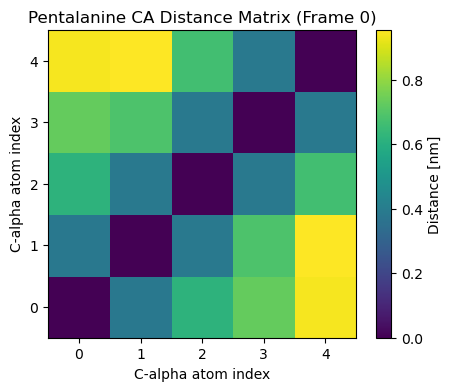

In [11]:
plt.figure(figsize=(5, 4))
plt.imshow(ca_dist_matrix[0], cmap='viridis', origin='lower')
plt.colorbar(label='Distance [nm]')
plt.xlabel('C-alpha atom index')
plt.ylabel('C-alpha atom index')
plt.title('Pentalanine CA Distance Matrix (Frame 0)')
plt.show()


### Distances between two different molecular systems

We can also measure distances between elements of two distinct molecular systems:


In [12]:
molsys_A = msm.extract(molsys, structure_indices=0)
molsys_B = msm.extract(molsys, structure_indices=1000)
cross_dist = msm.structure.get_distances(molsys_A, selection='atom_name=="CA"', molecular_system_2=molsys_B, selection_2='atom_name=="CA"')


In [13]:
cross_dist.shape


(1, 5, 5)

:::{seealso} Related Tools & References
:class: dropdown

- {ref}`Convert <Tutorial_Convert>`: Convert molecular systems between different forms with {func}`molsysmt.basic.convert`.
- {ref}`Get <Tutorial_Get>`: Retrieve coordinates and simulation time with {func}`molsysmt.basic.get`.
- {ref}`Extract <Tutorial_Extract>`: Extract structure frames or sub-systems with {func}`molsysmt.basic.extract`.
- {ref}`Get minimum distances <Tutorial_Get_minimum_distances>`: Find minimum pairwise distances with {func}`molsysmt.structure.get_minimum_distances`.
- {ref}`Get maximum distances <Tutorial_Get_maximum_distances>`: Find maximum pairwise distances with {func}`molsysmt.structure.get_maximum_distances`.
- {ref}`Get contacts <Tutorial_Get_contacts>`: Calculate boolean contact matrices with {func}`molsysmt.structure.get_contacts`.
:::
